<a href="https://colab.research.google.com/github/jaeho0726/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Import Libraries and Configuration**


In [1]:
import re

import urllib.request
import numpy as np
import pandas as pd
import os

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style("white")

from collections import Counter

from scipy.stats import pearsonr

## **2. Naver Movie Review Data: Loading and Initial Cleaning**

In [8]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = '/content/drive/MyDrive/Project/Sentiment_Analysis/klue_bert_model'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
if not os.path.exists(MODEL_PATH):
  # Accessing Naver movie review data
  train_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
  test_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")
  train_data = pd.read_table(train_file)
  test_data = pd.read_table(test_file)

  # Cleaning train data
  train_data.drop_duplicates(subset=['document'], inplace = True)
  train_data = train_data.dropna(how='any')
  train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
  train_data['document'] = train_data['document'].replace('', np.nan)
  train_data = train_data.dropna(how='any')

  # Cleaning test data
  test_data.drop_duplicates(subset=['document'], inplace = True)
  test_data = test_data.dropna(how='any')
  test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
  test_data['document'] = test_data['document'].replace('', np.nan)
  test_data = test_data.dropna(how='any')

  print("NSMC data loaded and cleaned")

else:
  print("Save model found - skipping NSMC data loading")

NSMC data loaded and cleaned


## **3. KLUE-BERT Model Preparation and Training**

In [11]:
class NSMCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=max_len)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [12]:
# Loading the KLUE-BERT Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH if os.path.exists(MODEL_PATH) else "klue/bert-base")

if os.path.exists(MODEL_PATH):
  # loading the saved model
  model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
  print("Saved model loaded")

else:
  train_dataset = NSMCDataset(train_data['document'].tolist(), train_data['label'].tolist(), tokenizer)
  test_dataset = NSMCDataset(test_data['document'].tolist(), test_data['label'].tolist(), tokenizer)

  model = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

  # Setting up training arguments
  training_args = TrainingArguments(
      output_dir='./results',
      num_train_epochs=1,
      per_device_train_batch_size=32,
      gradient_accumulation_steps=1,
      learning_rate=2e-5,
      logging_steps=100,
      fp16=True if torch.cuda.is_available() else False
  )

  # Initialize the Trainer and start training
  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset
  )

  trainer.train()

  model.save_pretrained(MODEL_PATH)
  tokenizer.save_pretrained(MODEL_PATH)
  print("Training complete. Model saved", MODEL_PATH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Step,Training Loss
100,0.453856
200,0.369009
300,0.347505
400,0.335963
500,0.311624
600,0.325388
700,0.328541
800,0.308546
900,0.316018
1000,0.309720


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete. Model saved /content/drive/MyDrive/Project/Sentiment_Analysis/klue_bert_model


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [14]:
def bert_predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        prob_positive = F.softmax(outputs.logits, dim=-1)[0][1].item()

        return (prob_positive - 0.5) * 200

## **4. Daily Journal Data: Loading and Applying Sentiment Score**

In [15]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()

gc = gspread.Client(auth=creds)

spreadsheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1DrDCLitpXZyJajcWYcMNcJCZU4Xa0aE_gj4sfXzl6x4/edit?gid=0#gid=0')

worksheet = spreadsheet.worksheet('data')

In [16]:
df = pd.DataFrame(worksheet.get_all_records())

# Shortening Column Names
df = df.rename(columns={
    "Work Intensity (0 - Easy / 10 - Intense)": "Work Intensity",
    "Overall Mood (0 - Poor / 10 - Great)": "Overall Mood",
    "Name": "Date"
})

# Fixing Data Types
df["Hours of Work"] = pd.to_numeric(df["Hours of Work"], errors="coerce").fillna(0)
df["Work Intensity"] = pd.to_numeric(df["Work Intensity"], errors="coerce").fillna(0)
df["Overall Mood"] = pd.to_numeric(df["Overall Mood"], errors="coerce").fillna(0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Day_of_Week'] = df['Date'].dt.day_name()


df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week
0,2026-01-24,On Duty,0.0,0,9,드디어 차수가 끝나고 비차수가 시작되었다. 비록 이번 차수는 엄청 힘들지는 않았지만...,Saturday
1,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday
3,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday
4,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday
...,...,...,...,...,...,...,...
113,2026-05-27,On Duty,8.0,1,6,검열이 반이나 지났다! 정확히 말하면 반 이상이나 했다! 오늘 하루종일 비가 와서 ...,Wednesday
114,2026-05-28,On Duty,8.0,2,6,내일이면 이제 말출 전 마지막 출근이다! 오늘 하루만 버티면 된다는 마인드로 오늘 ...,Thursday
115,2026-05-29,On Duty,7.0,1,7,드디어 기다리고 기다리던 이번주가 거의 다 지나갔다! 오늘까지만 잘 버티면 말출이 ...,Friday
116,2026-05-30,On Duty,0.0,0,8,내일이면 말출 시작이다! 기다리고 기다리던 이 날이 내일이면 온다는게 믿기지가 않는...,Saturday


In [17]:
df['Sentiment Score'] = df['Reflection'].apply(bert_predict)

df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week,Sentiment Score
0,2026-01-24,On Duty,0.0,0,9,드디어 차수가 끝나고 비차수가 시작되었다. 비록 이번 차수는 엄청 힘들지는 않았지만...,Saturday,89.849508
1,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday,-86.154708
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday,-28.789055
3,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday,40.903199
4,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday,0.659168
...,...,...,...,...,...,...,...,...
113,2026-05-27,On Duty,8.0,1,6,검열이 반이나 지났다! 정확히 말하면 반 이상이나 했다! 오늘 하루종일 비가 와서 ...,Wednesday,-15.451413
114,2026-05-28,On Duty,8.0,2,6,내일이면 이제 말출 전 마지막 출근이다! 오늘 하루만 버티면 된다는 마인드로 오늘 ...,Thursday,-51.280507
115,2026-05-29,On Duty,7.0,1,7,드디어 기다리고 기다리던 이번주가 거의 다 지나갔다! 오늘까지만 잘 버티면 말출이 ...,Friday,82.228041
116,2026-05-30,On Duty,0.0,0,8,내일이면 말출 시작이다! 기다리고 기다리던 이 날이 내일이면 온다는게 믿기지가 않는...,Saturday,-84.172174


In [18]:
def categorize_sentiment(score):
  if score > 0:
    return '긍정'
  elif score < 0:
    return '부정'
  else:
    return '중립'

df['Sentiment'] = df['Sentiment Score'].apply(categorize_sentiment)

df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week,Sentiment Score,Sentiment
0,2026-01-24,On Duty,0.0,0,9,드디어 차수가 끝나고 비차수가 시작되었다. 비록 이번 차수는 엄청 힘들지는 않았지만...,Saturday,89.849508,긍정
1,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday,-86.154708,부정
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday,-28.789055,부정
3,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday,40.903199,긍정
4,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday,0.659168,긍정
...,...,...,...,...,...,...,...,...,...
113,2026-05-27,On Duty,8.0,1,6,검열이 반이나 지났다! 정확히 말하면 반 이상이나 했다! 오늘 하루종일 비가 와서 ...,Wednesday,-15.451413,부정
114,2026-05-28,On Duty,8.0,2,6,내일이면 이제 말출 전 마지막 출근이다! 오늘 하루만 버티면 된다는 마인드로 오늘 ...,Thursday,-51.280507,부정
115,2026-05-29,On Duty,7.0,1,7,드디어 기다리고 기다리던 이번주가 거의 다 지나갔다! 오늘까지만 잘 버티면 말출이 ...,Friday,82.228041,긍정
116,2026-05-30,On Duty,0.0,0,8,내일이면 말출 시작이다! 기다리고 기다리던 이 날이 내일이면 온다는게 믿기지가 않는...,Saturday,-84.172174,부정


## **5. Visualization**

In [19]:
on_duty = df[df["Today's Status"] == "On Duty"].copy()

pos_df = df[df['Sentiment'] == '긍정'].copy()
neg_df = df[df['Sentiment'] == '부정'].copy()

In [20]:
def extract_korean_words(text_series):
    words = []
    for text in text_series:
        if isinstance(text, str):
            found = re.findall(r'[가-힣]{2,}', text)
            words.extend(found)
    return Counter(words)

# Common filler words to exclude
filler = {'오늘', '정말', '것이', '것도', '것을', '것은', '것같', '같다', '같은',
          '하지만', '그래도', '이번', '생각', '때문', '느낌', '그리고', '하면서',
          '있는', '있었', '없는', '없었', '했던', '했다', '했는데', '했고',
          '이라', '에서', '에게', '으로', '에도', '했을', '이었', '이다',
          '한다', '한것', '해서', '하고', '하는', '이번에', '오늘도', '그래서', '너무', '내가'}

def top_words(counter, n=30):
    return [(w, c) for w, c in counter.most_common(200)
            if w not in filler][:n]

print("Extracting words...")
pos_words = top_words(extract_korean_words(pos_df['Reflection']))
neg_words = top_words(extract_korean_words(neg_df['Reflection']))

Extracting words...


In [21]:
# High mood but negative sentiment
false_neg = df[(df['Overall Mood'] >= 7) & (df['Sentiment Score'] < 0)].copy()
# Low mood but positive sentiment
false_pos = df[(df['Overall Mood'] <= 4) & (df['Sentiment Score'] > 0)].copy()

df['Discrepancy Type'] = 'Aligned'
df.loc[false_neg.index, 'Discrepancy Type'] = 'High Mood / Negative Text'
df.loc[false_pos.index, 'Discrepancy Type'] = 'Low Mood / Positive Text'

### Mood vs Sentiment Discrepancy Scatter ###

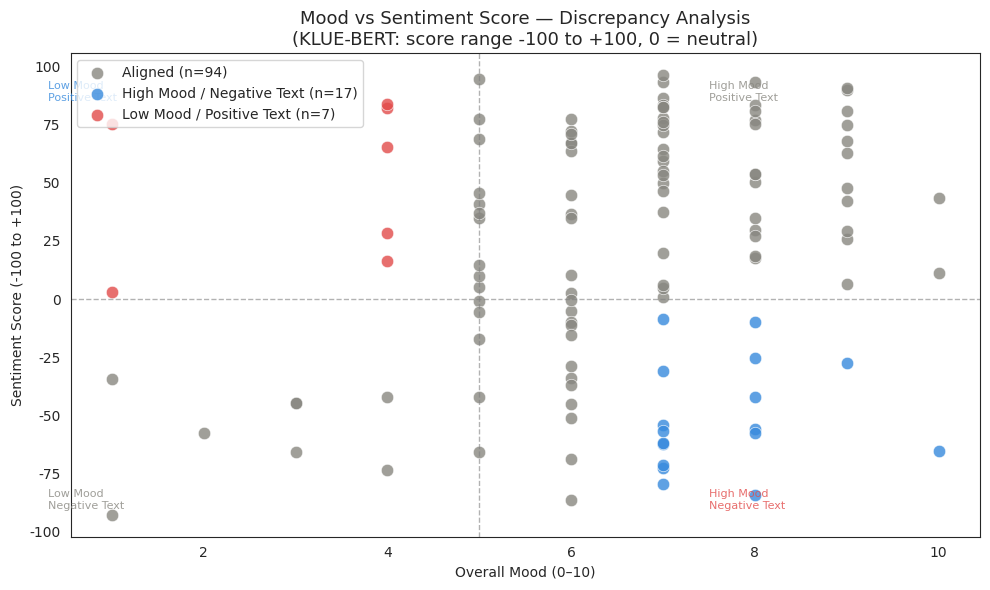

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_map = {
    'Aligned':                   '#888780',
    'High Mood / Negative Text': '#378ADD',
    'Low Mood / Positive Text':  '#E24B4A'
}
for dtype, group in df.groupby('Discrepancy Type'):
    ax1.scatter(group['Overall Mood'], group['Sentiment Score'],
                label=f"{dtype} (n={len(group)})",
                color=color_map[dtype], alpha=0.8, s=80,
                edgecolors='white', linewidths=0.5)

ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.axvline(5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_title('Mood vs Sentiment Score — Discrepancy Analysis\n(KLUE-BERT: score range -100 to +100, 0 = neutral)', fontsize=13)
ax1.set_xlabel('Overall Mood (0–10)')
ax1.set_ylabel('Sentiment Score (-100 to +100)')
ax1.legend(fontsize=10)

ax1.text(0.3, 85,  'Low Mood\nPositive Text',  fontsize=8, color='#378ADD', alpha=0.8)
ax1.text(7.5, 85,  'High Mood\nPositive Text', fontsize=8, color='#888780', alpha=0.8)
ax1.text(0.3, -90, 'Low Mood\nNegative Text',  fontsize=8, color='#888780', alpha=0.8)
ax1.text(7.5, -90, 'High Mood\nNegative Text', fontsize=8, color='#E24B4A', alpha=0.8)

plt.tight_layout()
plt.show()

### Hours of Work vs Sentiment Score ###

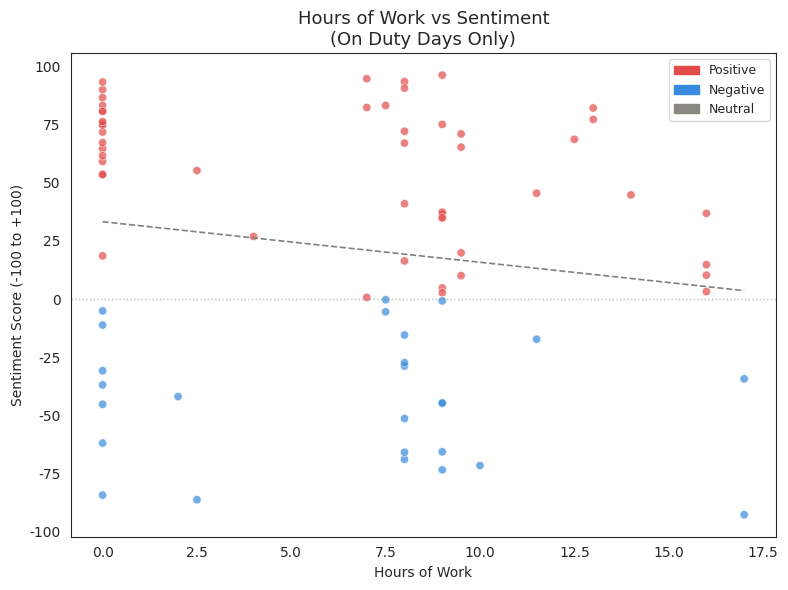

In [41]:
colors_duty = on_duty['Sentiment'].map({'긍정': '#E24B4A', '부정': '#378ADD', '중립': '#888780'})
legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Positive'),
    mpatches.Patch(color='#378ADD', label='Negative'),
    mpatches.Patch(color='#888780', label='Neutral')
]

fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(on_duty['Hours of Work'], on_duty['Sentiment Score'],
            c=colors_duty, alpha=0.7, edgecolors='white', linewidths=0.5)
if len(on_duty) > 1:
    m, b = np.polyfit(on_duty['Hours of Work'], on_duty['Sentiment Score'], 1)
    x_line = np.linspace(on_duty['Hours of Work'].min(), on_duty['Hours of Work'].max(), 100)
    ax2.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1.2)
ax2.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_title('Hours of Work vs Sentiment\n(On Duty Days Only)', fontsize=13)
ax2.set_xlabel('Hours of Work')
ax2.set_ylabel('Sentiment Score (-100 to +100)')
ax2.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.show()

### Work Intensity vs Sentiment Score ###

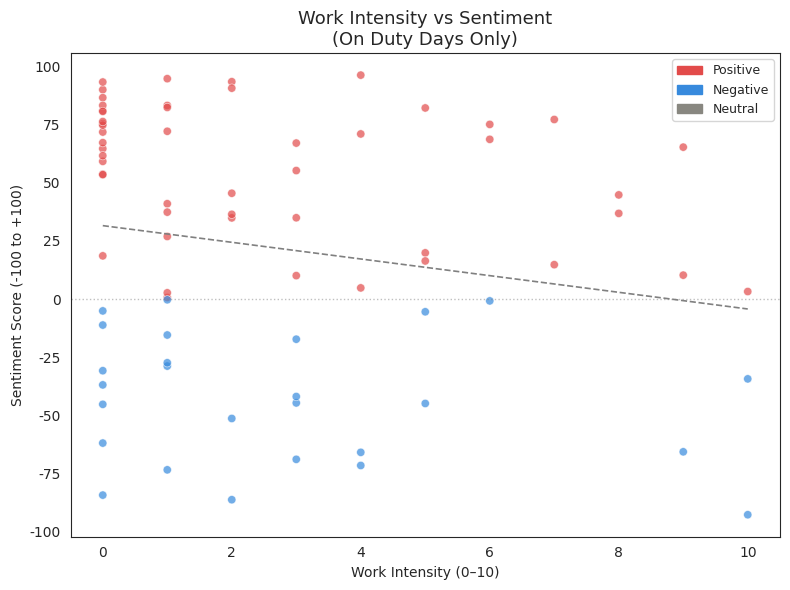

In [42]:
fig, ax3 = plt.subplots(figsize=(8, 6))
ax3.scatter(on_duty['Work Intensity'], on_duty['Sentiment Score'],
            c=colors_duty, alpha=0.7, edgecolors='white', linewidths=0.5)
if len(on_duty) > 1:
    m2, b2 = np.polyfit(on_duty['Work Intensity'], on_duty['Sentiment Score'], 1)
    x_line2 = np.linspace(on_duty['Work Intensity'].min(), on_duty['Work Intensity'].max(), 100)
    ax3.plot(x_line2, m2 * x_line2 + b2, color='gray', linestyle='--', linewidth=1.2)
ax3.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax3.set_title('Work Intensity vs Sentiment\n(On Duty Days Only)', fontsize=13)
ax3.set_xlabel('Work Intensity (0–10)')
ax3.set_ylabel('Sentiment Score (-100 to +100)')
ax3.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
# Calculate Pearson correlation between Sentiment Score and Overall Mood
# Note: pearsonr returns the correlation coefficient and the p-value.
correlation_coefficient, p_value = pearsonr(df['Sentiment Score'], df['Overall Mood'])

print(f"Pearson Correlation between Sentiment Score and Overall Mood: {correlation_coefficient:.3f}")
print(f"P-value: {p_value:.3f}")

if correlation_coefficient > 0.7:
    print("There is a strong positive correlation, suggesting the model's sentiment largely aligns with your overall mood.")
elif correlation_coefficient > 0.3:
    print("There is a moderate positive correlation.")
elif correlation_coefficient < -0.7:
    print("There is a strong negative correlation, which might indicate a mismatch or inverse relationship.")
elif correlation_coefficient < -0.3:
    print("There is a moderate negative correlation.")
else:
    print("The correlation is weak, suggesting a limited linear relationship between the sentiment score and overall mood.")

Pearson Correlation between Sentiment Score and Overall Mood: 0.224
P-value: 0.015
The correlation is weak, suggesting a limited linear relationship between the sentiment score and overall mood.
